# Heart Disease UCI — Classification multiclasse (num : 0 → 4)

**Objectif** : prédire la sévérité de la maladie cardiaque `num` (0 = sain, 1 à 4 = gravité croissante).

**Contrainte de l'exercice**
- **PySpark** est utilisé *uniquement* pour l'**analyse et le nettoyage** du dataset (traitement distribué).
- Le **modèle de classification** est entraîné avec **scikit-learn**.

**Plan**
1. Analyse exploratoire (EDA) avec PySpark
2. Nettoyage avec PySpark, puis passage du DataFrame Spark → pandas
3. Modélisation multiclasse avec scikit-learn (pipeline, entraînement, évaluation)
4. Bonus (cadrage binaire) & conclusion


## Partie 1 — Analyse exploratoire avec PySpark

On démarre la session Spark. On force Spark à utiliser **le même interpréteur Python que le notebook**
(sinon Spark cherche un `python3` système et échoue).

In [296]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("HeartDiseaseUCI")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version)

ConnectionRefusedError: [Errno 61] Connection refused

In [ ]:
# Chargement du CSV
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("heart_disease_uci.csv")
)
df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- sex: string (nullable = true)
 |-- dataset: string (nullable = true)
 |-- cp: string (nullable = true)
 |-- trestbps: integer (nullable = true)
 |-- chol: integer (nullable = true)
 |-- fbs: boolean (nullable = true)
 |-- restecg: string (nullable = true)
 |-- thalch: integer (nullable = true)
 |-- exang: boolean (nullable = true)
 |-- oldpeak: double (nullable = true)
 |-- slope: string (nullable = true)
 |-- ca: integer (nullable = true)
 |-- thal: string (nullable = true)
 |-- num: integer (nullable = true)



In [ ]:
# La colonne 'id' est un simple identifiant : on la retire, elle n'a aucune valeur prédictive
df = df.drop("id")
print("Lignes :", df.count(), "| Colonnes :", len(df.columns))
df.limit(5).toPandas()

Lignes : 920 | Colonnes : 15


/Users/nabzvecr-mac/Documents/esgi/tp-ia/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/nabzvecr-mac/Documents/esgi/tp-ia/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160,286,False,lv hypertrophy,108,True,1.5,flat,3,normal,2
2,67,Male,Cleveland,asymptomatic,120,229,False,lv hypertrophy,129,True,2.6,flat,2,reversable defect,1
3,37,Male,Cleveland,non-anginal,130,250,False,normal,187,False,3.5,downsloping,0,normal,0
4,41,Female,Cleveland,atypical angina,130,204,False,lv hypertrophy,172,False,1.4,upsloping,0,normal,0


In [ ]:
# On compte les "num" qui sont les classes qu'on veut obtenir

df.groupBy("num").count().orderBy("num").show()

+---+-----+
|num|count|
+---+-----+
|  0|  411|
|  1|  265|
|  2|  109|
|  3|  107|
|  4|   28|
+---+-----+



### 1.2 — Valeurs manquantes par colonne

In [ ]:
from pyspark.sql.functions import col, count, when

# On compte les valeurs nulles
df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df.columns
]).show()

+---+---+-------+---+--------+----+---+-------+------+-----+-------+-----+---+----+---+
|age|sex|dataset| cp|trestbps|chol|fbs|restecg|thalch|exang|oldpeak|slope| ca|thal|num|
+---+---+-------+---+--------+----+---+-------+------+-----+-------+-----+---+----+---+
|  0|  0|      0|  0|      59|  30| 90|      2|    55|   55|     62|  309|611| 486|  0|
+---+---+-------+---+--------+----+---+-------+------+-----+-------+-----+---+----+---+



On remarque beaucoup de valeurs nulles, trop importantes pour les retirer, donc on les remplacera par des valeurs estimées 

### 1.3 — Distributions & valeurs aberrantes (histogrammes)

Un graphique se dessine côté *driver* : **Spark sélectionne** les colonnes numériques, puis on ramène
l'extrait (920 lignes) en pandas **uniquement pour tracer**.

Un histogramme découpe chaque variable en **barres** (intervalles de valeurs). Une barre **isolée**,
détachée du reste de la distribution, trahit une valeur anormale. À repérer : la grande barre **à 0**
sur `chol` et `trestbps` (mesures physiologiquement impossibles → manquants déguisés, voir 1.4) et les
barres en zone **négative** de `oldpeak`.

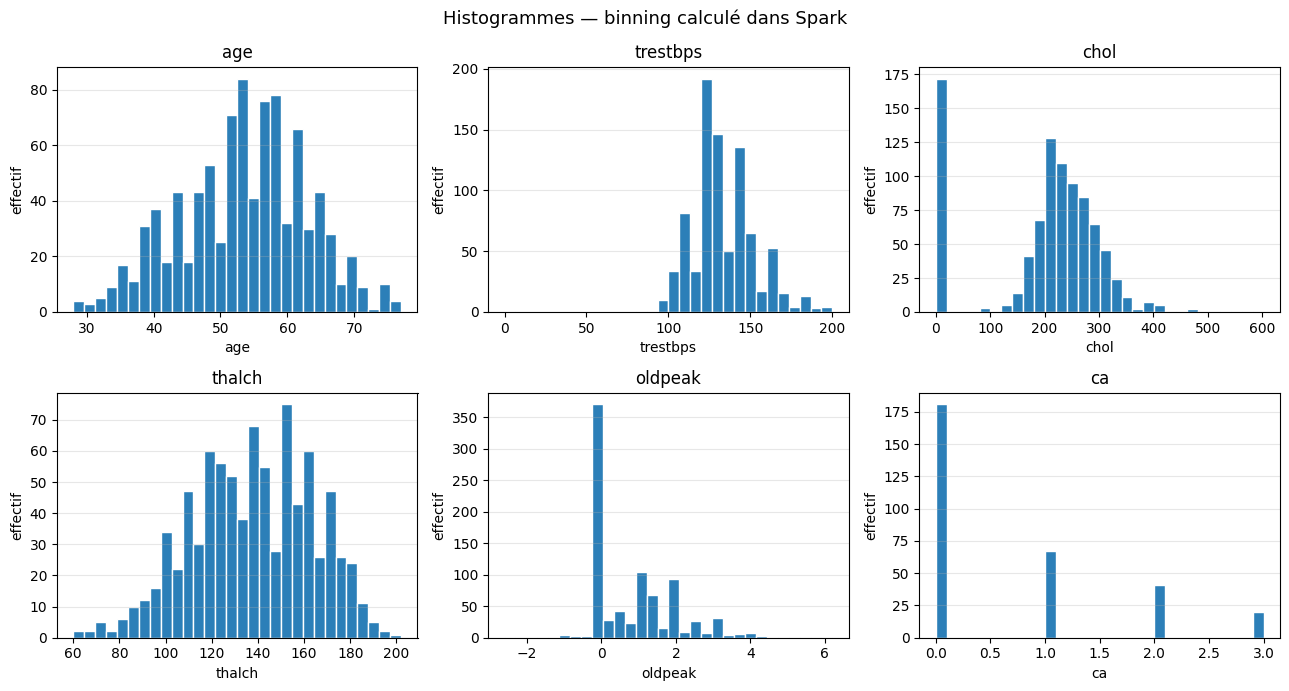

In [ ]:
import matplotlib.pyplot as plt

num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), num_cols):
    # Binning calculé DANS Spark : seuls les bords + effectifs reviennent au driver
    edges, counts = (
        df.select(c).na.drop()
                .rdd.map(lambda r: float(r[0]))
                .histogram(30)
    )
    widths = [edges[i + 1] - edges[i] for i in range(len(counts))]
    ax.bar(edges[:-1], counts, width=widths, align="edge",
           color="#2c7fb8", edgecolor="white")
    ax.set_title(c); ax.set_xlabel(c); ax.set_ylabel("effectif")
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Histogrammes — binning calculé dans Spark", fontsize=13)
plt.tight_layout()
plt.show()

On remarque des valeurs aberrantes sur le cholesterol, la pression du sang et peut-être oldpeak mais 0 est considéré normal (pas de dépression du ST)

### 1.5 — Statistiques descriptives des variables numériques

In [ ]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
df.select(num_cols).describe().toPandas()

/Users/nabzvecr-mac/Documents/esgi/tp-ia/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/nabzvecr-mac/Documents/esgi/tp-ia/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,summary,age,trestbps,chol,thalch,oldpeak,ca
0,count,920,861,890,865,858,309
1,mean,53.51086956521739,132.13240418118468,199.13033707865168,137.5456647398844,0.8787878787878787,0.6763754045307443
2,stddev,9.424685209576863,19.066069518587465,110.78081035323052,25.92627649279756,1.09122624834653,0.9356530125599869
3,min,28,0,0,60,-2.6,0
4,max,77,200,603,202,6.2,3


### 1.6 — Variables catégorielles

#### Répartition des modalités (camemberts)

Équivalent catégoriel des histogrammes numériques : la part de chaque modalité. La tranche
**« manquant »** rend la missingness visible (ex. `thal` ≈ 53 %, `slope` ≈ 34 %).

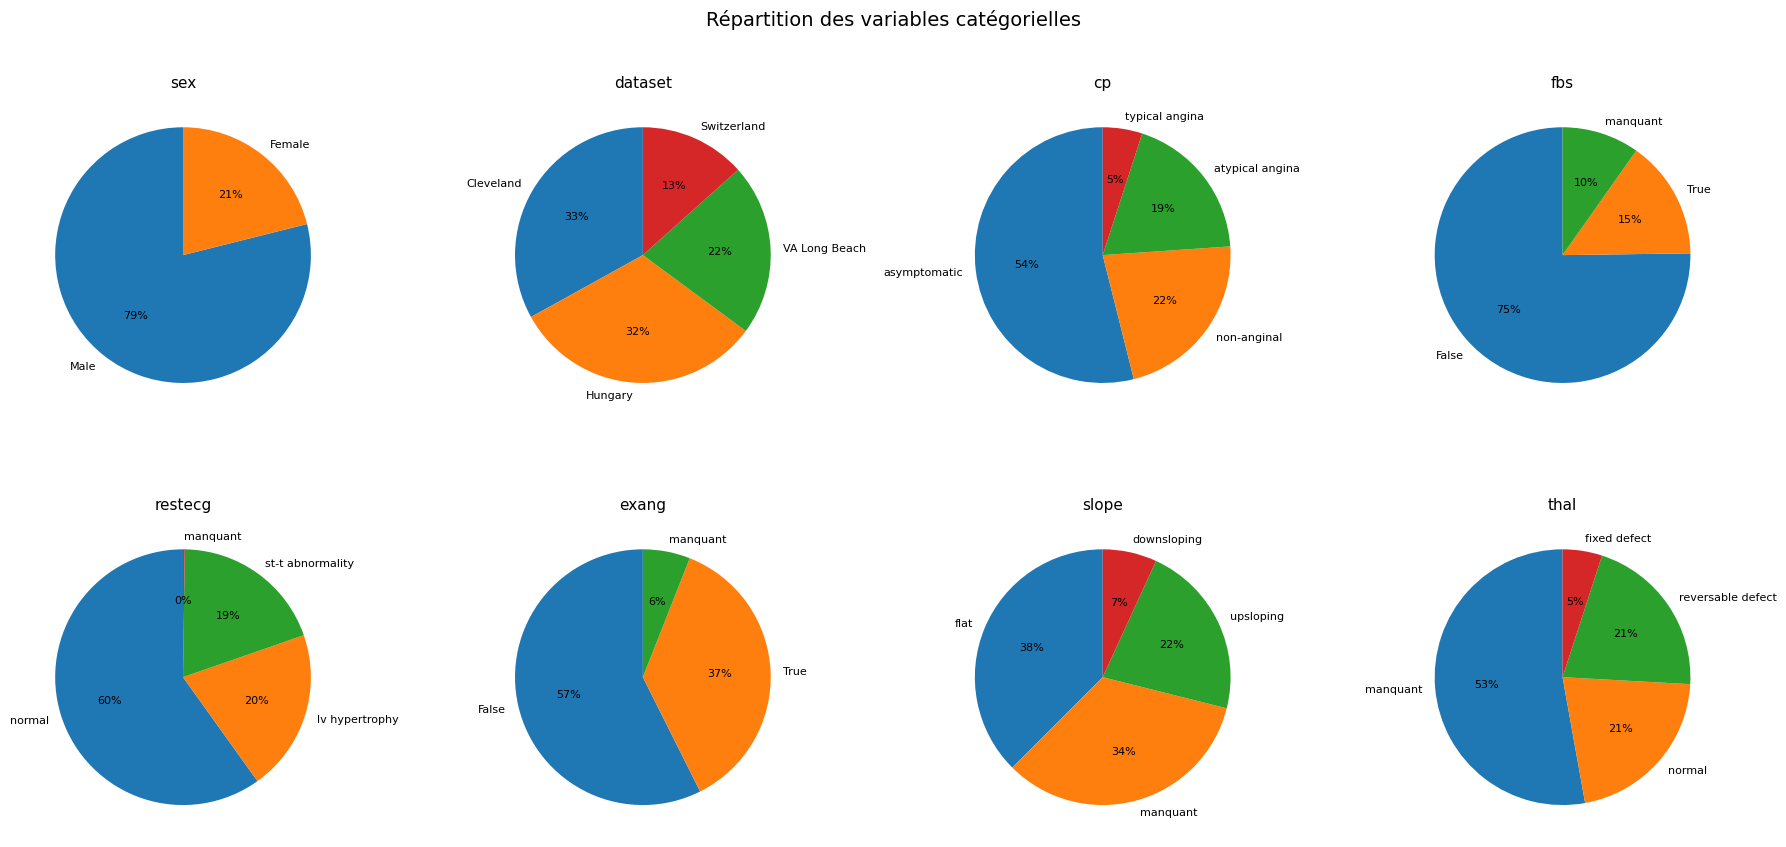

In [ ]:
import matplotlib.pyplot as plt

cat_cols = ["sex", "dataset", "cp", "fbs", "restecg", "exang", "slope", "thal"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, c in zip(axes.ravel(), cat_cols):
    # Comptage des modalités dans Spark (NULL inclus, affiché "manquant")
    counts = df.groupBy(c).count().orderBy(F.desc("count")).collect()
    labels = [str(r[c]) if r[c] is not None else "manquant" for r in counts]
    sizes = [r["count"] for r in counts]
    ax.pie(sizes, labels=labels, autopct="%1.0f%%", startangle=90,
           textprops={"fontsize": 8})
    ax.set_title(c, fontsize=11)
fig.suptitle("Répartition des variables catégorielles", fontsize=14)
plt.tight_layout()
plt.show()

#### Taux de malades par modalité — quelles catégories sont des facteurs de risque ?

Le simple comptage ci-dessus ne dit pas *quelle* modalité est liée à la maladie. On calcule donc,
pour chaque modalité, le **taux de malades** (`num > 0`) : un taux élevé = facteur de risque.

In [ ]:
# Taux de malades (num > 0) par modalité — 100 % PySpark
from functools import reduce
cat_cols = ["sex", "dataset", "cp", "fbs", "restecg", "exang", "slope", "thal"]
def taux_table(c):
    return (df.groupBy(c)
              .agg(F.count("*").alias("effectif"),
                   F.round(F.avg((F.col("num") > 0).cast("int")) * 100).alias("taux_malade_%"))
              .select(F.lit(c).alias("variable"),
                      F.coalesce(F.col(c).cast("string"), F.lit("NULL (manquant)")).alias("modalité"),
                      F.col("effectif"), F.col("taux_malade_%")))
tab = reduce(lambda a, b: a.unionByName(b), [taux_table(c) for c in cat_cols])
tab.orderBy("variable", F.desc("taux_malade_%")).toPandas()

/Users/nabzvecr-mac/Documents/esgi/tp-ia/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/nabzvecr-mac/Documents/esgi/tp-ia/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,variable,modalité,effectif,taux_malade_%
0,cp,asymptomatic,496,79.0
1,cp,typical angina,46,43.0
2,cp,non-anginal,204,36.0
3,cp,atypical angina,174,14.0
4,dataset,Switzerland,123,93.0
5,dataset,VA Long Beach,200,75.0
6,dataset,Cleveland,304,46.0
7,dataset,Hungary,293,36.0
8,exang,true,337,84.0
9,exang,NULL (manquant),55,64.0


### 1.7 — Recherche de signal : la cible varie-t-elle avec les features ?

On regarde la moyenne de quelques variables numériques selon la sévérité `num`.
Si les moyennes diffèrent nettement entre classes, la variable est discriminante.

In [ ]:
(
    df.groupBy("num")
      .agg(
          F.round(F.avg("age"), 1).alias("age_moy"),
          F.round(F.avg("thalch"), 1).alias("max_bpm_moy"),
          F.round(F.avg("oldpeak"), 2).alias("ST_depr_moy"),
          F.round(F.avg("ca"), 2).alias("major_vessels_moy"),
          F.round(F.avg("chol"), 2).alias("chol_moy"),
          F.round(F.avg("trestbps"), 2).alias("rest_blood_pressure_moy"),
      )
      .orderBy("num")
      .toPandas()
)

/Users/nabzvecr-mac/Documents/esgi/tp-ia/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/nabzvecr-mac/Documents/esgi/tp-ia/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,num,age_moy,max_bpm_moy,ST_depr_moy,major_vessels_moy,chol_moy,rest_blood_pressure_moy
0,0,50.5,148.8,0.42,0.28,227.91,129.91
1,1,53.5,131.0,1.00,0.74,195.26,132.86
2,2,57.6,128.7,1.35,1.22,143.86,133.61
3,3,59.2,120.5,1.58,1.46,159.72,136.15
4,4,59.2,127.8,2.31,1.69,192.15,138.72


In [ ]:
# Type de douleur (cp) chez les MALADES (num > 0) — appuie le paradoxe de l'ischémie silencieuse
malades = df.filter(F.col("num") > 0)
n_malades = malades.count()

(malades.groupBy("cp").count()
        .withColumn("pct_des_malades", F.round(F.col("count") / n_malades * 100, 0))
        .orderBy(F.desc("count"))
        .show())

n_asympt = malades.filter(F.col("cp") == "asymptomatic").count()
print(f"{n_asympt} malades sur {n_malades} sont 'asymptomatic' "
      f"({n_asympt / n_malades * 100:.0f}%) : la douleur typique manque chez la majorité des malades.")

+---------------+-----+---------------+
|             cp|count|pct_des_malades|
+---------------+-----+---------------+
|   asymptomatic|  392|           77.0|
|    non-anginal|   73|           14.0|
|atypical angina|   24|            5.0|
| typical angina|   20|            4.0|
+---------------+-----+---------------+

392 malades sur 509 sont 'asymptomatic' (77%) : la douleur typique manque chez la majorité des malades.


## Partie 2 — Nettoyage avec PySpark

Trois étapes :
1. **Corrections objectives** (indépendantes des autres lignes) : doublons, `chol==0`, `trestbps==0`.
2. **Imputation** des valeurs manquantes (médiane / mode).
3. **Handoff** vers pandas pour scikit-learn.

Corrections objectives retenues :

| Problème détecté en Partie 1 | Lignes | Action |
|---|---|---|
| Doublons complets | 2 | suppression (`dropDuplicates`) |
| `chol == 0` (cholestérol nul impossible) | 172 | → `null` |
| `trestbps == 0` (pression nulle impossible) | 1 | → `null` |

**Décision assumée — `oldpeak < 0` (12 valeurs) : conservé** (probables élévations ST réelles, cf.
Partie 1). Un format inhabituel n'est pas une erreur.

In [ ]:
# Nettoyage : uniquement des corrections objectives (AUCUNE imputation ici)
df_clean = (
    df.dropDuplicates()                                                                     # 2 doublons complets
      .withColumn("chol",     when(col("chol") == 0, None).otherwise(col("chol")))          # 0 = manquant déguisé
      .withColumn("trestbps", when(col("trestbps") == 0, None).otherwise(col("trestbps")))  # 0 = manquant déguisé
)
# NB : oldpeak < 0 est volontairement CONSERVÉ (probables élévations ST réelles, cf. Partie 1)

print("Lignes :", df.count(), "->", df_clean.count(), "(doublons retirés)")

# Contrôle : nb de null par colonne APRÈS nettoyage (seuls chol / trestbps augmentent)
df_clean.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df_clean.columns
]).toPandas()

Lignes : 920 -> 918 (doublons retirés)


/Users/nabzvecr-mac/Documents/esgi/tp-ia/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/nabzvecr-mac/Documents/esgi/tp-ia/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,0,0,0,0,60,201,90,2,55,55,62,307,609,484,0


### 2.1 — Imputation des valeurs manquantes (médiane / mode)

On remplit les trous **dans Spark** :
- **numériques** → **médiane** (robuste aux extrêmes, ex. `chol` jusqu'à 603) ;
- **catégorielles** → **mode** (modalité la plus fréquente).


In [ ]:
from pyspark.ml.feature import Imputer

num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
cat_cols = ["sex", "dataset", "cp", "fbs", "restecg", "exang", "slope", "thal"]

# Numériques -> médiane
imputer = Imputer(strategy="median", inputCols=num_cols, outputCols=num_cols)
df_num = imputer.fit(df_clean).transform(df_clean)

# Catégorielles -> mode (modalité la plus fréquente, calculée hors null)
modes = {}
for c in cat_cols:
    top = (df_clean.filter(col(c).isNotNull())
                   .groupBy(c).count().orderBy(F.desc("count")).first())
    modes[c] = top[0]
df_imputed = df_num.na.fill(modes)

print("Modes utilisés :", modes)

# Contrôle : plus aucun null nulle part
df_imputed.select([count(when(col(c).isNull(), c)).alias(c) for c in df_imputed.columns]).toPandas()

Modes utilisés : {'sex': 'Male', 'dataset': 'Cleveland', 'cp': 'asymptomatic', 'fbs': False, 'restecg': 'normal', 'exang': False, 'slope': 'flat', 'thal': 'normal'}


/Users/nabzvecr-mac/Documents/esgi/tp-ia/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/nabzvecr-mac/Documents/esgi/tp-ia/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### 2.2 — Handoff Spark → numpy

Le dataset est petit (918 lignes) : on le ramène en mémoire pour scikit-learn — **sans pandas**, via
`collect()` puis conversion en tableaux **numpy**. On ferme ensuite la session Spark.

In [ ]:
# Écriture Spark -> disque (ni collect(), ni toPandas())
(
    df_imputed
    .select(*num_cols, *cat_cols, "num")
    .coalesce(1)
    .write.mode("overwrite")
    .option("header", True)
    .csv("heart_disease_final_csv")
)
spark.stop()

# Lecture indépendante avec pandas
import glob
import pandas as pd
import numpy as np

csv_path = glob.glob("heart_disease_final_csv/part-*.csv")[0]
pdf_final = pd.read_csv(csv_path)

X = pdf_final[num_cols + cat_cols].astype(
    {c: str for c in cat_cols}
).to_numpy(dtype=object)
y = pdf_final["num"].to_numpy(dtype=int)

print("X :", X.shape, "| y :", y.shape, "| classes :", sorted(set(y.tolist())))

## Partie 3 — Modélisation multiclasse avec scikit-learn

Les données sont déjà **nettoyées et imputées** (Partie 2) et transmises en **numpy** (pas de pandas).
Le pipeline ne fait donc plus que :

- **numériques** → standardisation (`StandardScaler`) ;
- **catégorielles** → encodage One-Hot (`OneHotEncoder`).

Les colonnes sont désignées par **indice** (un tableau numpy n'a pas de noms de colonnes). On compare
ensuite 3 modèles.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             balanced_accuracy_score, f1_score)

In [ ]:
# num_cols / cat_cols viennent de la Partie 2 ; on repère les colonnes par INDICE dans X
num_idx = list(range(len(num_cols)))
cat_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

print("Numériques  (indices) :", num_idx)
print("Catégorielles (indices) :", cat_idx)

Numériques  (indices) : [0, 1, 2, 3, 4, 5]
Catégorielles (indices) : [6, 7, 8, 9, 10, 11, 12, 13]


In [ ]:
# Prétraitement : plus d'imputation (déjà faite en Partie 2), juste standardisation + one-hot
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_idx),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_idx),
])

In [ ]:
# Split stratifié (on préserve la proportion des classes, cruciale vu le déséquilibre)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train :", X_train.shape[0], "| Test :", X_test.shape[0])

Train : 734 | Test : 184


### 3.1 — Modèle principal : Random Forest

`class_weight="balanced_subsample"` compense le déséquilibre en pondérant les classes rares.

In [ ]:
rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )),
])
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy          :", round((y_pred == y_test).mean(), 3))
print("Balanced accuracy :", round(balanced_accuracy_score(y_test, y_pred), 3))
print("F1 macro          :", round(f1_score(y_test, y_pred, average='macro'), 3))
print()
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy          : 0.587
Balanced accuracy : 0.368
F1 macro          : 0.364

              precision    recall  f1-score   support

           0       0.85      0.83      0.84        82
           1       0.61      0.58      0.60        53
           2       0.08      0.09      0.09        22
           3       0.27      0.33      0.30        21
           4       0.00      0.00      0.00         6

    accuracy                           0.59       184
   macro avg       0.36      0.37      0.36       184
weighted avg       0.59      0.59      0.59       184



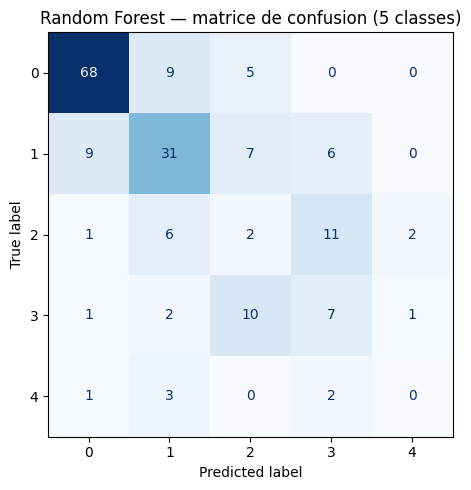

In [ ]:
# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Random Forest — matrice de confusion (5 classes)")
plt.tight_layout()
plt.show()

### 3.2 — Comparaison de modèles

`HistGradientBoosting` gère nativement les valeurs manquantes ; la régression logistique sert de
référence linéaire.

In [ ]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2,
        class_weight="balanced_subsample", random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, random_state=42),
    "LogisticRegression": LogisticRegression(
        max_iter=2000, class_weight="balanced"),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"{'modèle':22s}{'accuracy_cv':>13s}{'f1_macro_cv':>13s}")
print("-" * 48)
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()
    f1m = cross_val_score(pipe, X, y, cv=cv, scoring="f1_macro", n_jobs=-1).mean()
    print(f"{name:22s}{acc:13.3f}{f1m:13.3f}")

modèle                  accuracy_cv  f1_macro_cv
------------------------------------------------
RandomForest                  0.581        0.386
HistGradientBoosting          0.564        0.368
LogisticRegression            0.549        0.405


### 3.3 — Importance des variables (Random Forest)

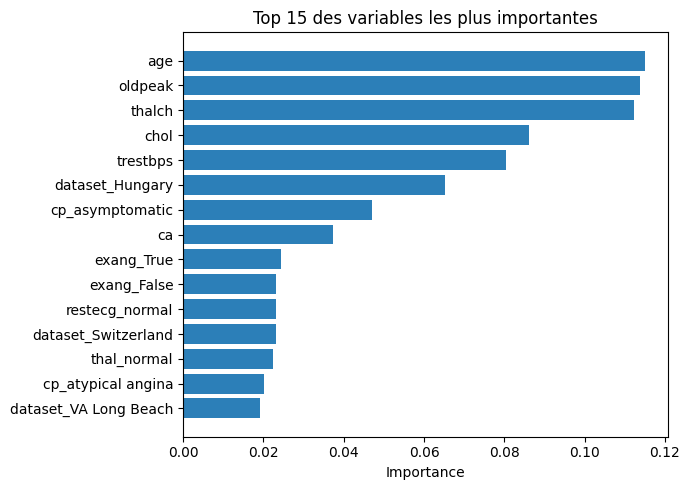

In [ ]:
rf.fit(X_train, y_train)

# Noms des features reconstruits (numpy n'a pas de noms) : numériques + modalités one-hot
ohe = rf.named_steps["prep"].named_transformers_["cat"]
feat_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
importances = rf.named_steps["clf"].feature_importances_

order = np.argsort(importances)[::-1][:15]      # les 15 plus importantes

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh([feat_names[i] for i in order][::-1],
        [importances[i] for i in order][::-1], color="#2c7fb8")
ax.set_title("Top 15 des variables les plus importantes")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## Partie 4 — Bonus : cadrage binaire & conclusion

Le problème à **5 classes est intrinsèquement difficile** : les classes 1-2-3-4 se distinguent mal
entre elles (symptômes proches, 28 cas seulement pour la classe 4). C'est pourquoi la littérature
sur ce dataset utilise souvent une cible **binaire** : *malade (num > 0)* vs *sain (num = 0)*.
On le montre à titre de comparaison — les performances sont nettement meilleures.

In [ ]:
y_bin = (y > 0).astype(int)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    X, y_bin, test_size=0.2, stratify=y_bin, random_state=42)

rf_bin = Pipeline([("prep", preprocessor),
                   ("clf", RandomForestClassifier(
                       n_estimators=400, min_samples_leaf=2,
                       class_weight="balanced", random_state=42, n_jobs=-1))])
rf_bin.fit(Xb_tr, yb_tr)
yb_pred = rf_bin.predict(Xb_te)

print("BINAIRE (sain vs malade)")
print("Accuracy :", round((yb_pred == yb_te).mean(), 3))
print(classification_report(yb_te, yb_pred, target_names=["sain", "malade"], zero_division=0))

BINAIRE (sain vs malade)
Accuracy : 0.837
              precision    recall  f1-score   support

        sain       0.82      0.82      0.82        82
      malade       0.85      0.85      0.85       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



### 4.1 — Variante 3 classes (bandes de sévérité)

Les niveaux 3 et 4 étant statistiquement inséparables (cf. Partie 1), on regroupe la cible en
**3 bandes cliniques** : `0` = sain, `1-2` = atteinte modérée, `3-4` = atteinte sévère. On gagne
~10 points d'accuracy tout en conservant une prédiction de **gravité** — compromis assumé et
médicalement défendable.

3 CLASSES (0 / 1-2 / 3-4)
Accuracy          : 0.69
Balanced accuracy : 0.595
F1 macro          : 0.599

              precision    recall  f1-score   support

    sain (0)       0.86      0.79      0.82        82
modéré (1-2)       0.62      0.73      0.67        75
sévère (3-4)       0.37      0.26      0.30        27

    accuracy                           0.69       184
   macro avg       0.61      0.60      0.60       184
weighted avg       0.69      0.69      0.68       184



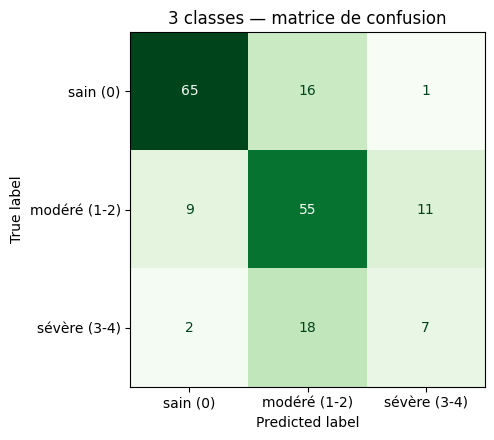

26/07/17 20:50:35 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:70)
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:44)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:34)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(Blo

In [ ]:
# Cible regroupée : 0 (sain) / 1-2 (modéré) / 3-4 (sévère)
y3 = np.select([y == 0, (y >= 1) & (y <= 2), y >= 3], [0, 1, 2])
labels3 = ["sain (0)", "modéré (1-2)", "sévère (3-4)"]

X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X, y3, test_size=0.2, stratify=y3, random_state=42)

rf3 = Pipeline([("prep", preprocessor),
                ("clf", RandomForestClassifier(
                    n_estimators=400, min_samples_leaf=2,
                    class_weight="balanced_subsample", random_state=42, n_jobs=-1))])
rf3.fit(X3_tr, y3_tr)
y3_pred = rf3.predict(X3_te)

print("3 CLASSES (0 / 1-2 / 3-4)")
print("Accuracy          :", round((y3_pred == y3_te).mean(), 3))
print("Balanced accuracy :", round(balanced_accuracy_score(y3_te, y3_pred), 3))
print("F1 macro          :", round(f1_score(y3_te, y3_pred, average="macro"), 3))
print()
print(classification_report(y3_te, y3_pred, target_names=labels3, zero_division=0))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y3_te, y3_pred, display_labels=labels3,
                                        ax=ax, cmap="Greens", colorbar=False)
ax.set_title("3 classes — matrice de confusion")
plt.tight_layout()
plt.show()

## Conclusion

- **PySpark** a servi à charger, explorer, **nettoyer et imputer** le dataset ; le handoff vers
  scikit-learn s'est fait en **numpy** (aucun pandas).
- **scikit-learn** entraîne le classifieur multiclasse via un **pipeline** (standardisation + One-Hot →
  modèle).
- Sur les **5 classes**, on obtient ~55-60 % d'accuracy : la classe 0 est bien détectée, mais les
  classes 2/3/4 restent difficiles (peu d'exemples, signal quasi inexistant pour les séparer). Les
  métriques *balanced accuracy* et *F1 macro* sont les plus honnêtes ici.
- Pour un usage pratique (dépistage sain/malade), le **cadrage binaire** dépasse 80 % d'accuracy.

**Pistes d'amélioration** : regrouper les classes (0 / 1-2 / 3-4)